In [1]:
%cd /content

!rm -rf SimpleNet SimpleNet.zip
!wget -O SimpleNet.zip https://github.com/DonaldRR/SimpleNet/archive/refs/heads/main.zip
!unzip -q SimpleNet.zip
!mv SimpleNet-main SimpleNet

%cd /content/SimpleNet
!ls

/content
--2026-05-17 16:08:41--  https://github.com/DonaldRR/SimpleNet/archive/refs/heads/main.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/DonaldRR/SimpleNet/zip/refs/heads/main [following]
--2026-05-17 16:08:41--  https://codeload.github.com/DonaldRR/SimpleNet/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 140.82.113.9
Connecting to codeload.github.com (codeload.github.com)|140.82.113.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘SimpleNet.zip’

SimpleNet.zip           [  <=>               ] 235.43K   974KB/s    in 0.2s    

2026-05-17 16:08:42 (974 KB/s) - ‘SimpleNet.zip’ saved [241079]

/content/SimpleNet
backbones.py  datasets	LICENSE  metrics.py  resnet.py	simplenet.py  VERSION
common.py     imgs	main.py  README.md  

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/SimpleNet

from pathlib import Path

# 1. Fix metrics.py (pandas append bug)
path = Path("metrics.py")
text = path.read_text()
old = 'df = df.append({"pro": np.mean(pros), "fpr": fpr, "threshold": th}, ignore_index=True)'
new = 'df.loc[len(df)] = {"pro": np.mean(pros), "fpr": fpr, "threshold": th}'
text = text.replace(old, new)
path.write_text(text)

# 2. Fix main.py (visualization bug)
main_path = Path("main.py")
main_content = main_path.read_text()
main_content = main_content.replace('# i_auroc, p_auroc, pro_auroc =  SimpleNet.test', 'i_auroc, p_auroc, pro_auroc = SimpleNet.test')
main_content = main_content.replace('print("Warning: Pls set test with true by default")', 'pass')
train_call = 'i_auroc, p_auroc, pro_auroc = SimpleNet.train(dataloaders["training"], dataloaders["testing"])'
train_and_test = train_call + '\n            if save_segmentation_images: SimpleNet.test(dataloaders["training"], dataloaders["testing"], save_segmentation_images)'
main_content = main_content.replace(train_call, train_and_test)
main_path.write_text(main_content)

print("Bug fixes applied for visualization.")

/content/SimpleNet
Bug fixes applied for visualization.


In [5]:
%cd /content/SimpleNet

!python3 main.py \
--gpu 0 \
--seed 0 \
--log_group simplenet_mvtec \
--log_project MVTecAD_Results \
--results_path results \
--run_name toothbrush_visual \
--save_segmentation_images \
net \
-b wideresnet50 \
-le layer2 \
-le layer3 \
--pretrain_embed_dimension 1536 \
--target_embed_dimension 1536 \
--patchsize 3 \
--meta_epochs 40 \
--embedding_size 256 \
--gan_epochs 4 \
--noise_std 0.015 \
--dsc_hidden 1024 \
--dsc_layers 2 \
--dsc_margin .5 \
--pre_proj 1 \
dataset \
--batch_size 4 \
--resize 256 \
--imagesize 224 \
-d toothbrush \
mvtec /content/drive/MyDrive/anormaly_detection/mvtec

/content/SimpleNet
2026-05-17 16:10:15.808709: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO:__main__:Command line arguments: main.py --gpu 0 --seed 0 --log_group simplenet_mvtec --log_project MVTecAD_Results --results_path results --run_name toothbrush_visual --save_segmentation_images net -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1536 --target_embed_dimension 1536 --patchsize 3 --meta_epochs 40 --embedding_size 256 --gan_epochs 4 --noise_std 0.015 --dsc_hidden 1024 --dsc_layers 2 --dsc_margin .5 --pre_proj 1 dataset --batch_size 4 --resize 256 --imagesize 224 -d toothbrush mvtec /content/drive/MyDrive/anormaly_detection/mvtec
INFO:__main__:Dataset: train=60 test=42
INFO:__main__:Evaluating dataset [mvtec_toothbrush

In [6]:
import pandas as pd
import glob

csvs = glob.glob("/content/SimpleNet/results/**/*.csv", recursive=True)
if csvs:
    df = pd.read_csv(csvs[-1])
    display(df)
else:
    print("Results CSV not found.")

,Row Names,instance_auroc,full_pixel_auroc,anomaly_pixel_auroc
0,mvtec_toothbrush,1.0,0.984708,0.915281
1,Mean,1.0,0.984708,0.915281


Found 42 visualization images.


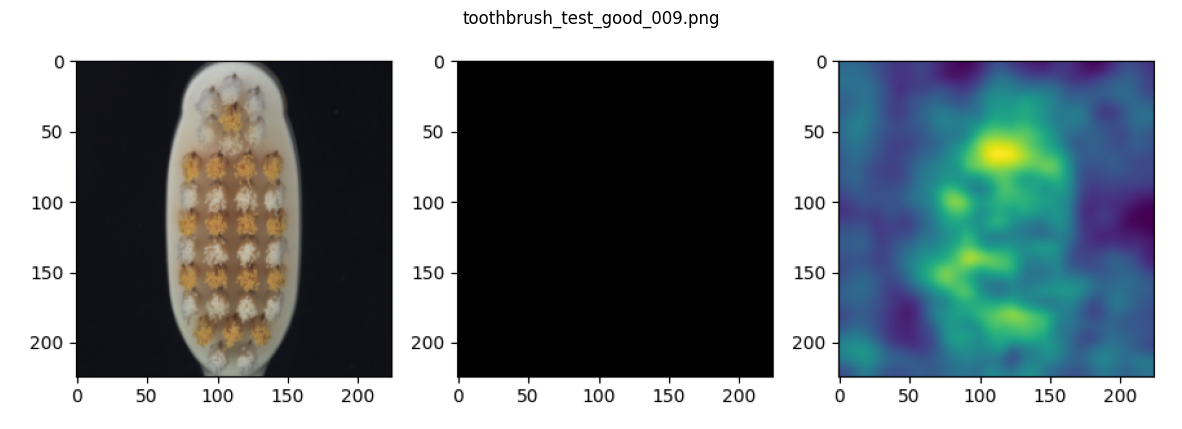

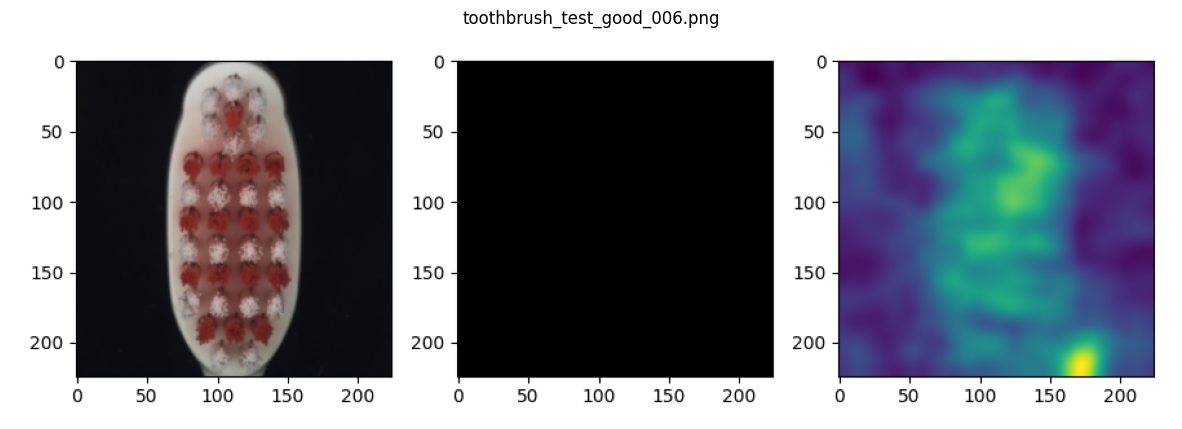

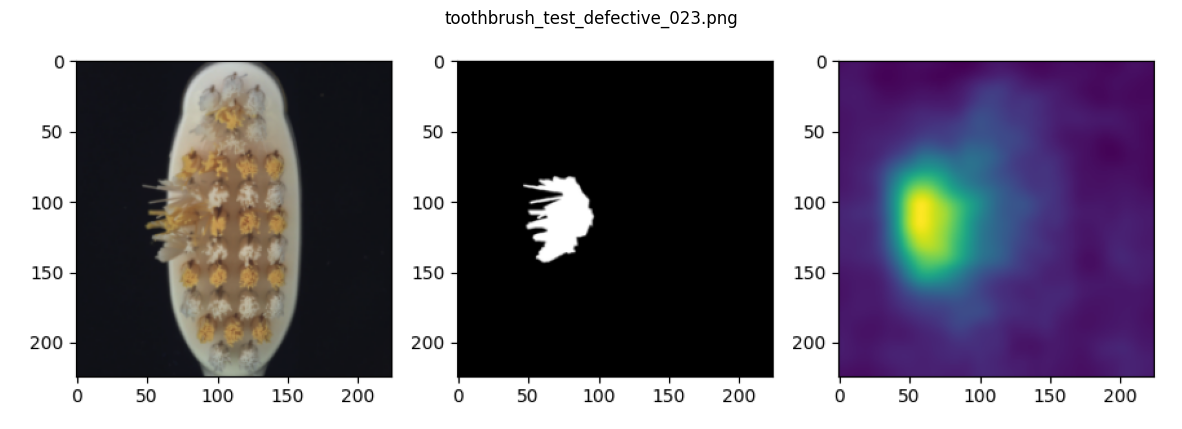

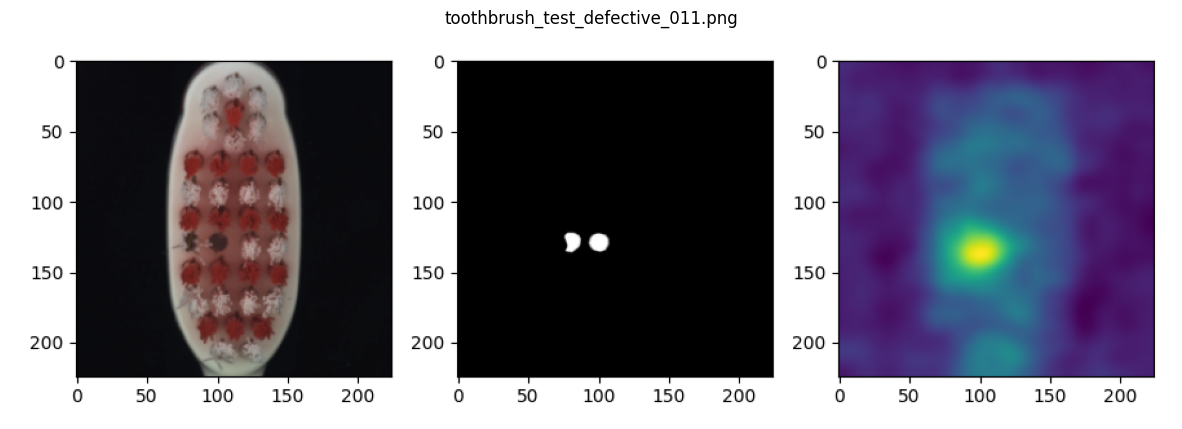

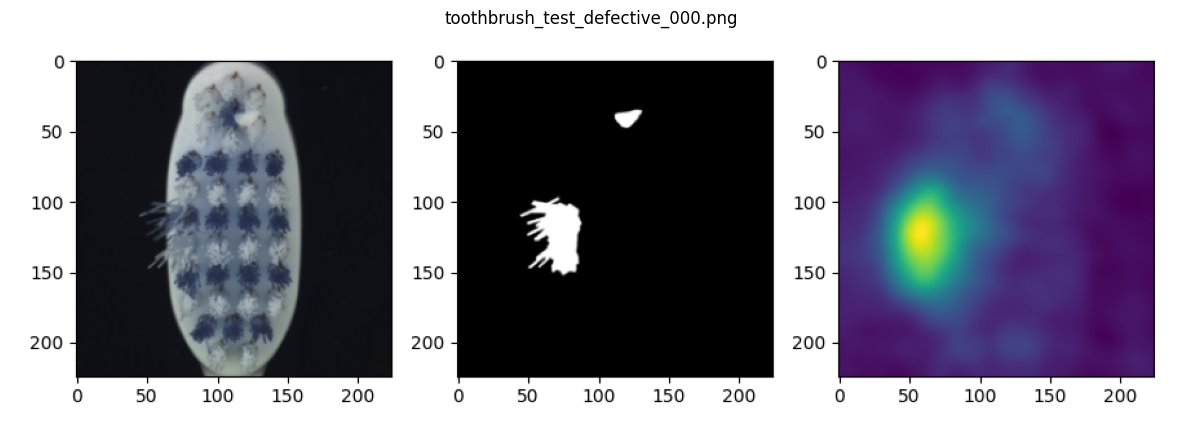

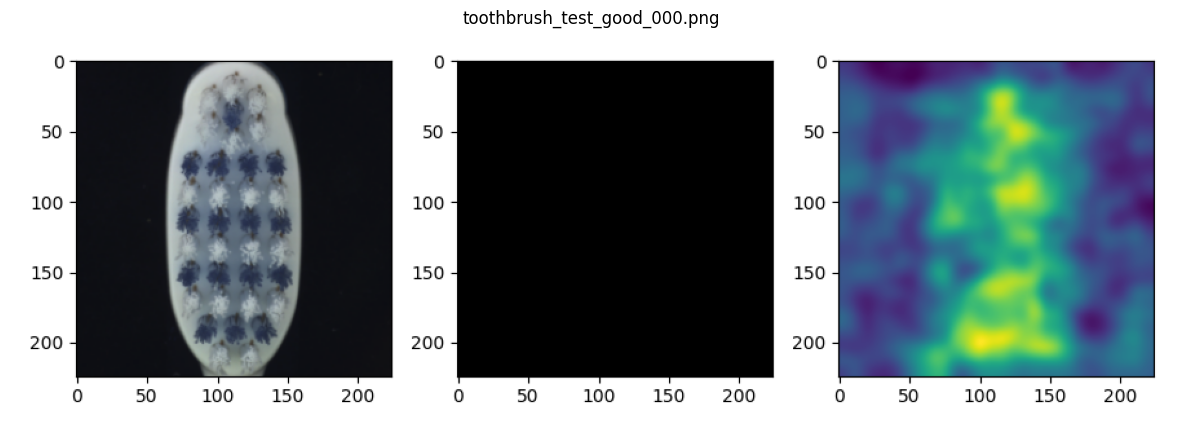

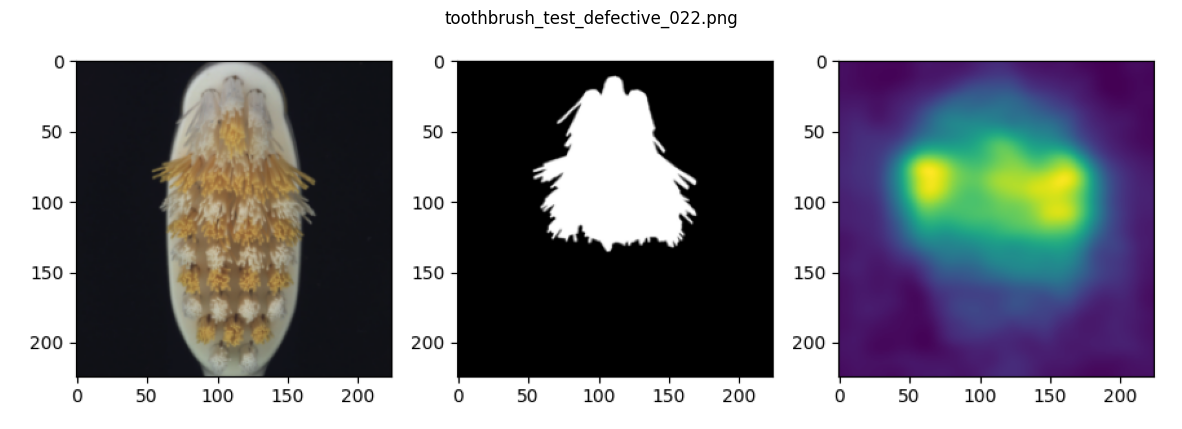

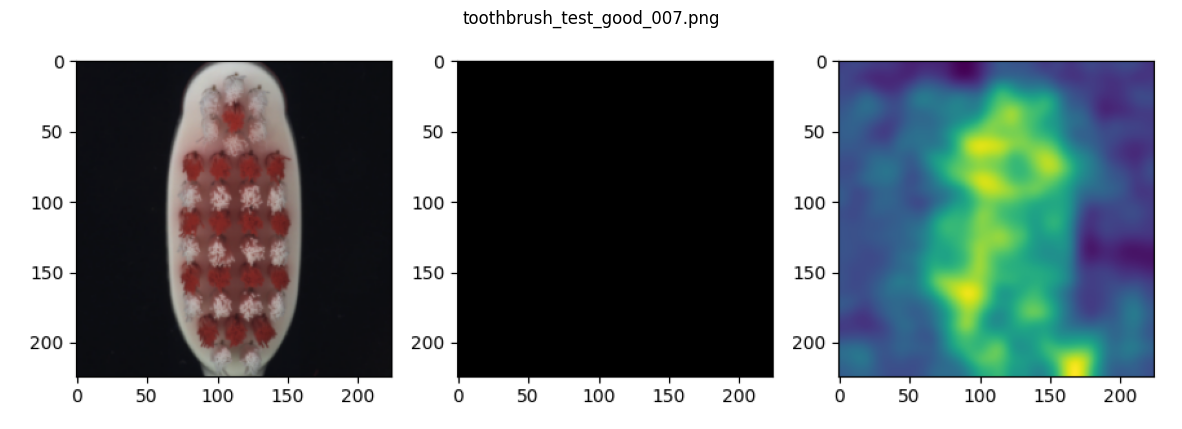

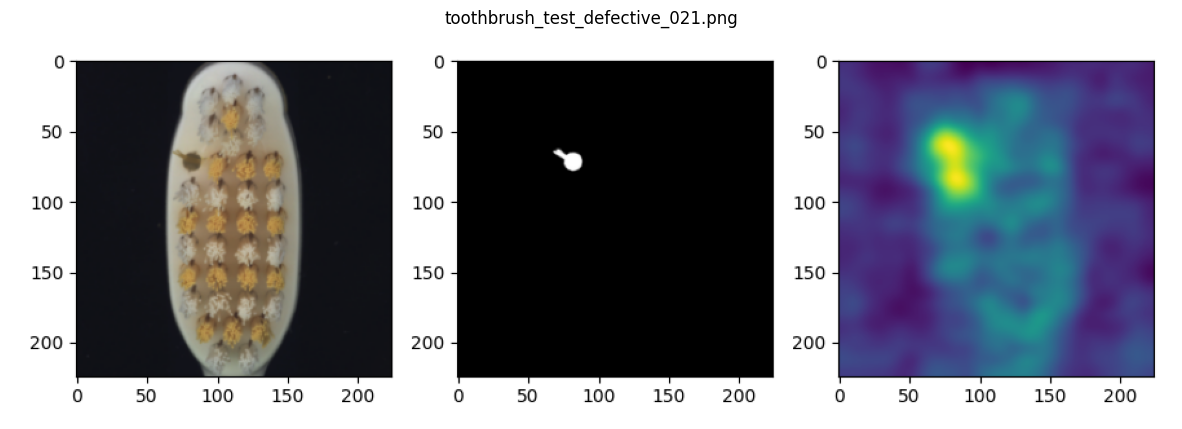

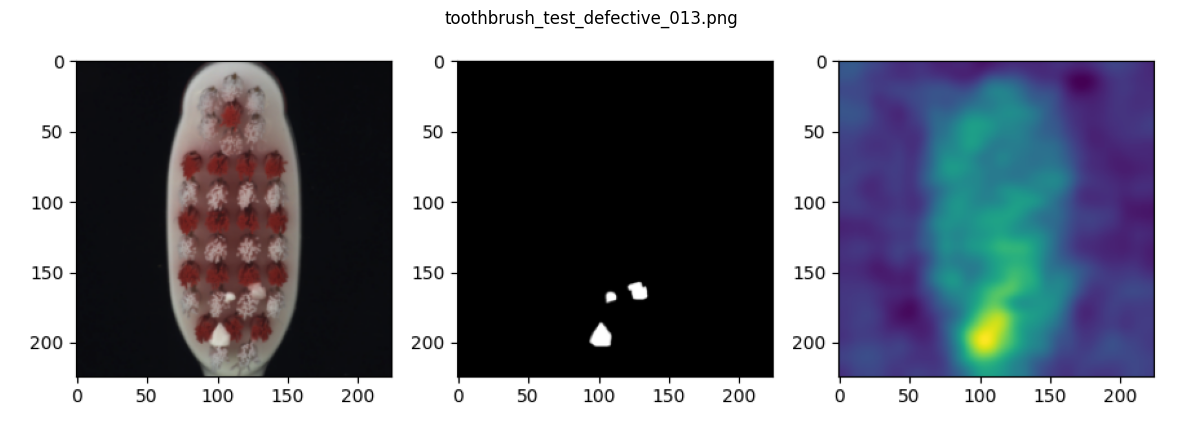

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import glob
import os

image_files = glob.glob("/content/SimpleNet/output/*.png")

if not image_files:
    print("No visualization images found. Check /content/SimpleNet/output")
else:
    print(f"Found {len(image_files)} visualization images.")
    for img_path in image_files[:10]:
        plt.figure(figsize=(15, 8))
        plt.imshow(Image.open(img_path))
        plt.title(os.path.basename(img_path))
        plt.axis('off')
        plt.show()